In [1]:
import os

base_path = r'C:\Users\Admin\OneDrive\Desktop\CNN\plantvillage'

for item in os.listdir(base_path):
    item_path = os.path.join(base_path, item)
    if os.path.isdir(item_path):
        num_images = len(os.listdir(item_path))
        print(f"{item}/ — {num_images} images")

Pepper__bell___Bacterial_spot/ — 978 images
Pepper__bell___healthy/ — 1478 images
PlantVillage/ — 15 images
Potato___Early_blight/ — 1000 images
Potato___healthy/ — 152 images
Potato___Late_blight/ — 1000 images
Tomato_Bacterial_spot/ — 2127 images
Tomato_Early_blight/ — 1000 images
Tomato_healthy/ — 1591 images
Tomato_Late_blight/ — 1909 images
Tomato_Leaf_Mold/ — 952 images
Tomato_Septoria_leaf_spot/ — 1771 images
Tomato_Spider_mites_Two_spotted_spider_mite/ — 1676 images
Tomato__Target_Spot/ — 1404 images
Tomato__Tomato_mosaic_virus/ — 373 images
Tomato__Tomato_YellowLeaf__Curl_Virus/ — 3209 images


In [2]:
import os
import shutil

rogue = r'C:\Users\Admin\OneDrive\Desktop\CNN\plantvillage\PlantVillage'
print(os.listdir(rogue))  # check what's inside first

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [4]:
import tensorflow as tf

base_path = r'C:\Users\Admin\OneDrive\Desktop\CNN\plantvillage'

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
print(f"Total classes: {len(class_names)}")
print(class_names)

Found 41257 files belonging to 16 classes.
Using 33006 files for training.
Found 41257 files belonging to 16 classes.
Using 8251 files for validation.
Total classes: 16
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


Image batch shape: (32, 224, 224, 3)
Pixel range: 0 to 255
Dtype: <dtype: 'float32'>


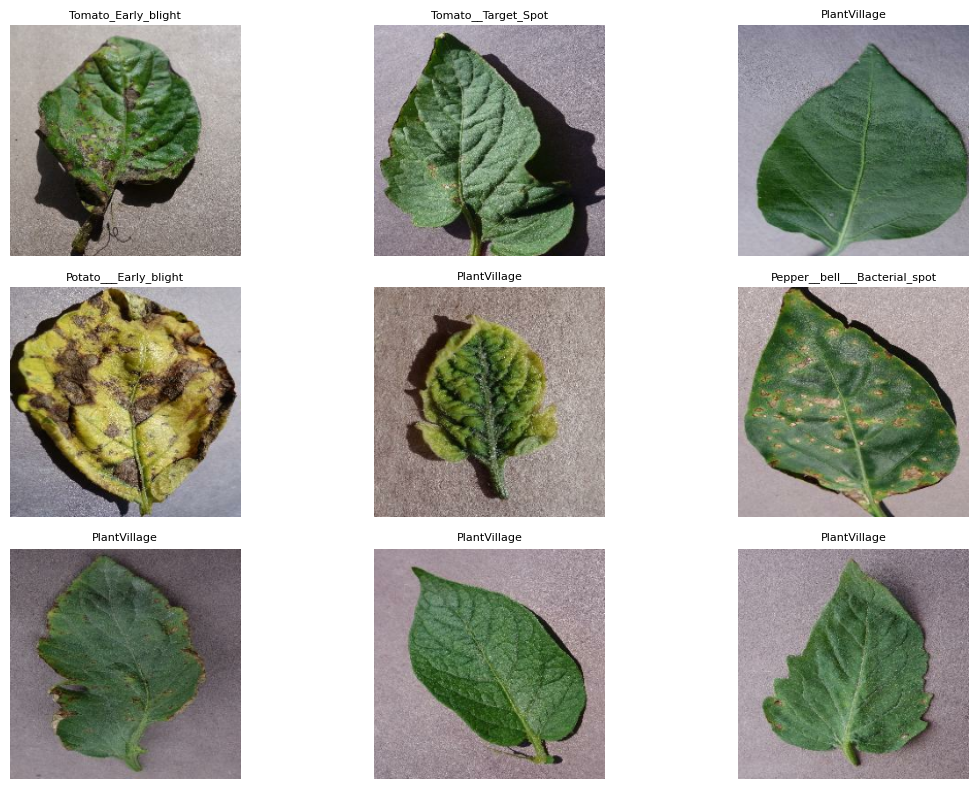

In [5]:
import matplotlib.pyplot as plt

# check pixel range
for images, labels in train_ds.take(1):
    print(f"Image batch shape: {images.shape}")
    print(f"Pixel range: {images.numpy().min():.0f} to {images.numpy().max():.0f}")
    print(f"Dtype: {images.dtype}")

# visualize
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]], fontsize=8)
        plt.axis('off')
plt.tight_layout()
plt.show()